In [31]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from featureEngineer import engineer_features
import warnings

from pathlib import Path
import sys
import os
from datetime import datetime
from dataScraper import *

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

df = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
df.head()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION
23311,2025-26,1630611,Gui Santos,Gui,1610612744,GSW,Golden State Warriors,22500002,2025-10-21T00:00:00,GSW @ LAL,W,2.646667,0,0,0.000,0,0,0.000,0,0,0.0,0,0,0,0,1,0,0,0,0,0,0,0,-1.0,0,0,0.0,1,2:39,1,94.9,100.0,100.0,123.0,120.0,120.0,-28.0,-20.0,-20.0,0.000,0.0,0.0,0.000,0.000,0.000,100.0,100.0,0.000,0.000,0.167,0.158,101.56,99.75,83.12,99.75,-0.111,6,0.0,0.0,38,78,0.487,17,40,0.425,26,29,0.897,9,31,40,29,19.0,10,4,2,27,21,119,10.0,118.1,119.0,106.5,106.9,11.6,12.1,0.763,1.53,21.0,0.209,0.744,0.477,0.190,0.596,0.656,101.5,101.00,84.17,100,0.546,1610612747,LAL,Los Angeles Lakers,42,77,0.545,8,32,0.250,17,28,0.607,7,32,39,23,20.0,7,2,4,21,27,109,-10.0,106.5,106.9,118.1,119.0,-11.6,-12.1,0.548,1.15,16.9,0.256,0.791,0.523,0.196,0.597,0.61,101.5,101.00,84.17,102,0.454,NaN
23288,2025-26,1627936,Alex Caruso,Alex,1610612760,OKC,Oklahoma City Thunder,22500001,2025-10-21T00:00:00,OKC vs. HOU,W,30.180000,3,9,0.333,2,6,0.333,0,0,0.0,0,2,2,3,0,2,1,1,2,1,8,-15,23.9,0,0,21.0,1,30:11,1,95.2,94.9,94.9,105.4,109.2,109.2,-10.2,-14.3,-14.3,0.167,0.0,25.0,0.000,0.077,0.036,0.0,0.0,0.444,0.444,0.141,0.146,100.36,98.61,82.17,98.61,0.076,59,3.0,9.0,46,104,0.442,13,52,0.250,20,25,0.800,11,27,38,29,12.0,12,4,5,27,26,125,1.0,107.8,112.6,103.6,107.8,4.1,4.8,0.630,2.42,18.5,0.283,0.518,0.397,0.108,0.505,0.543,97.5,93.52,77.93,111,0.521,1610612745,HOU,Houston Rockets,43,97,0.443,11,39,0.282,27,31,0.871,16,36,52,23,25.0,6,5,4,26,27,124,-1.0,103.6,107.8,107.8,112.6,-4.1,-4.8,0.535,0.92,13.9,0.482,0.717,0.603,0.217,0.500,0.56,97.5,93.52,77.93,115,0.479,NaN
23287,2025-26,1628392,Isaiah Hartenstein,Isaiah,1610612760,OKC,Oklahoma City Thunder,22500001,2025-10-21T00:00:00,OKC vs. HOU,W,36.841667,2,5,0.400,0,1,0.000,2,2,1.0,5,3,8,5,1,2,0,0,6,5,6,9,28.1,0,0,23.0,1,36:51,1,113.5,121.7,121.7,100.3,102.7,102.7,13.2,19.0,19.0,0.172,5.0,41.7,0.125,0.079,0.103,8.3,8.4,0.400,0.510,0.083,0.082,96.96,92.50,77.09,92.50,0.071,69,2.0,5.0,46,104,0.442,13,52,0.250,20,25,0.800,11,27,38,29,12.0,12,4,5,27,26,125,1.0,107.8,112.6,103.6,107.8,4.1,4.8,0.630,2.42,18.5,0.283,0.518,0.397,0.108,0.505,0.543,97.5,93.52,77.93,111,0.521,1610612745,HOU,Houston Rockets,43,97,0.443,11,39,0.282,27,31,0.871,16,36,52,23,25.0,6,5,4,26,27,124,-1.0,103.6,107.8,107.8,112.6,-4.1,-4.8,0.535,0.92,13.9,0.482,0.717,0.603,0.217,0.500,0.56,97.5,93.52,77.93,115,0.479,C
23286,2025-26,1627741,Buddy Hield,Buddy,1610612744,GSW,Golden State Warriors,

In [3]:
df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)
 
# Derived features
df['MIN'] = df['MIN'].round(2)
df['PF_PER_MIN'] = df['PF'] / df['MIN'].replace(0, np.nan)
df["PTS_PER_MIN"] = df["PTS"] / df["MIN"].replace(0, np.nan)
df["IS_HOME"]     = df["MATCHUP"].str.contains("vs\\.").astype(int)
df["SPREAD_PROXY"] = df["TEAM_PLUS_MINUS"]  # actual outcome; use betting spread at prediction time
df['STARTING'] = df['START_POSITION'].notna().astype(int)
df = engineer_features(df)
df['TEAM_PTS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_roll10'].rank(ascending=False, method='dense'))
df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
df['TEAM_TS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['TS_PCT_roll10'].rank(ascending=False, method='dense'))
df['MEDIAN_MIN_ROLLING_10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).median().round(2)))
df["PTS_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
df['PTS_ewm10'] = (df.groupby('PLAYER_ID')['PTS'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
df['MIN_ewm10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
df["GP"] = df.groupby("PLAYER_ID").cumcount()  # 0-indexed; GP=0 means first game
df["BLOWOUT_RISK"] = df.groupby("PLAYER_ID")["TEAM_PLUS_MINUS"].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std())
df['MIN_TREND'] = df['MIN_roll3'] - df['MIN_roll10']
df[df['PLAYER_ID'] == 2544].tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,PF_PER_MIN,PTS_PER_MIN,IS_HOME,SPREAD_PROXY,STARTING,MIN_roll3,PTS_roll3,USG_PCT_roll3,PF_roll3,PLUS_MINUS_roll3,POSS_roll3,PTS_PER_MIN_roll3,PF_PER_MIN_roll3,TS_PCT_roll3,AST_TO_roll3,NET_RATING_roll3,MIN_roll5,PTS_roll5,USG_PCT_roll5,PF_roll5,PLUS_MINUS_roll5,POSS_roll5,PTS_PER_MIN_roll5,PF_PER_MIN_roll5,TS_PCT_roll5,AST_TO_roll5,NET_RATING_roll5,MIN_roll10,PTS_roll10,USG_PCT_roll10,PF_roll10,PLUS_MINUS_roll10,POSS_roll10,PTS_PER_MIN_roll10,PF_PER_MIN_roll10,TS_PCT_roll10,AST_TO_roll10,NET_RATING_roll10,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,STARTER_ROLL10_PCT,MIN_season_avg,PTS_season_avg,USG_PCT_season_avg,POSS_season_avg,PF_season_avg,OFF_RATING_season_avg,DEF_RATING_season_avg,TEAM_PACE_roll5,TEAM_PTS_roll5,TEAM_NET_RATING_roll5,MIN_share_proxy,PTS_share_proxy,TEAM_POSS_roll5,TEAM_POSS_share,DAYS_REST,IS_B2B,GAME_NUMBER,MIN_std10,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,TEAM_PTS_RANK_L10,TEAM_MIN_RANK_L10,TEAM_USG_RANK_L10,TEAM_TS_RANK_L10,MEDIAN_MIN_ROLLING_10,PTS_PER_MIN_10_ewm,PTS_ewm10,MIN_ewm10,GP,BLOWOUT_RISK,MIN_TREND
46,2025-26,2544,LeBron James,LeBron,1610612747,LAL,Los Angeles Lakers,22500989,2026-03-16,LAL @ HOU,W,33.37,7,13,0.538,1,3,0.333,3,4,0.750,1,4,5,5,1,2,0,1,4,2,18,13,36.5,0,0,33.0,1,33:22,1,114.8,112.1,112.1,93.9,95.3,95.3,20.9,16.8,16.8,0.250,5.00,23.8,0.034,0.154,0.091,4.8,4.8,0.577,0.610,0.219,0.224,93.10,93.51,77.92,93.51,0.158,66,7.0,13.0,37,84,0.440,8,34,0.235,18,22,0.818,12,20,32,17,12.0,14,2,3,18,18,100,8.0,106.7,107.5,97.3,101.1,9.5,6.4,0.459,1.42,13.6,0.333,0.524,0.422,0.129,0.488,0.534,94.1,92.0,76.67,93,0.513,1610612745,HOU,Houston Rockets,38,79,0.481,5,26,0.192,11,15,0.733,15,29,44,21,24.0,9,3,2,18,18,92,-8.0,97.3,101.1,106.7,107.5,-9.5,-6.4,0.553,0.88,15.9,0.476,0.667,0.578,0.264,0.513,0.537,94.1,92.0,76.67,91,0.487,F,0.119868,0.539407,0,8.0,1,35.72,17.00,0.20,1.67,2.67,75.67,0.48,0.05,0.61,3.58,3.63,33.48,19.2,0.23,1.4,4.8,71.2,0.573477,0.04,0.64,2.76,8.76,32.99,18.7,0.25,1.3,3.3,68.4,0.58,0.04,0.60,3.05,6.44,40.22,17.0,6.0,0.091,1.0,84.0,33.23,18.0,12.0,0.121,1.0,73.0,1.0,33.26,21.26,0.27,69.67,1.35,114.03,113.9,99.52,125.4,11.34,0.14,0.15,71.2,1.0,2.0,0,46,3.65,117.32,115.34,98.10,96.96,98.0,97.9,3.0,3.0,2.0,6.0,33.35,0.575862,19.080023,33.915530,46,11.554220,2.

In [4]:
# Drop stale prior columns so re-running this cell does not merge into prior_mean_x / prior_mean_y
_prior_stale = [
    c
    for c in df.columns
    if c in ("prior_mean", "prior_std")
    or c.startswith("prior_mean_")
    or c.startswith("prior_std_")
]
if _prior_stale:
    df = df.drop(columns=_prior_stale)

league_prior = (
    df.groupby("STARTING")["PTS_PER_MIN"]
    .agg(prior_mean="mean", prior_std="std")
    .reset_index()
)
df = df.merge(league_prior, on="STARTING", how="left")

# Conjugate normal–normal posterior mean (vectorized)
prior_m = df["prior_mean"]
prior_v = (df["prior_std"] ** 2).clip(lower=1e-12)

obs_mean = df["PTS_PER_MIN_10_ewm"].where(df["PTS_PER_MIN_10_ewm"].notna(), prior_m)
obs_n = df["GP"].clip(upper=20)
obs_var = prior_v

prior_prec = 1 / prior_v
obs_prec = obs_n / obs_var
posterior_mean = (prior_prec * prior_m + obs_prec * obs_mean) / (prior_prec + obs_prec)

df["BAYES_PTS_PER_MIN"] = np.where(obs_n.to_numpy() == 0, prior_m.to_numpy(), posterior_mean.to_numpy())
df.head()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,PF_PER_MIN,PTS_PER_MIN,IS_HOME,SPREAD_PROXY,STARTING,MIN_roll3,PTS_roll3,USG_PCT_roll3,PF_roll3,PLUS_MINUS_roll3,POSS_roll3,PTS_PER_MIN_roll3,PF_PER_MIN_roll3,TS_PCT_roll3,AST_TO_roll3,NET_RATING_roll3,MIN_roll5,PTS_roll5,USG_PCT_roll5,PF_roll5,PLUS_MINUS_roll5,POSS_roll5,PTS_PER_MIN_roll5,PF_PER_MIN_roll5,TS_PCT_roll5,AST_TO_roll5,NET_RATING_roll5,MIN_roll10,PTS_roll10,USG_PCT_roll10,PF_roll10,PLUS_MINUS_roll10,POSS_roll10,PTS_PER_MIN_roll10,PF_PER_MIN_roll10,TS_PCT_roll10,AST_TO_roll10,NET_RATING_roll10,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,STARTER_ROLL10_PCT,MIN_season_avg,PTS_season_avg,USG_PCT_season_avg,POSS_season_avg,PF_season_avg,OFF_RATING_season_avg,DEF_RATING_season_avg,TEAM_PACE_roll5,TEAM_PTS_roll5,TEAM_NET_RATING_roll5,MIN_share_proxy,PTS_share_proxy,TEAM_POSS_roll5,TEAM_POSS_share,DAYS_REST,IS_B2B,GAME_NUMBER,MIN_std10,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,TEAM_PTS_RANK_L10,TEAM_MIN_RANK_L10,TEAM_USG_RANK_L10,TEAM_TS_RANK_L10,MEDIAN_MIN_ROLLING_10,PTS_PER_MIN_10_ewm,PTS_ewm10,MIN_ewm10,GP,BLOWOUT_RISK,MIN_TREND,prior_mean,prior_std,BAYES_PTS_PER_MIN
0,2025-26,2544,LeBron James,LeBron,1610612747,LAL,Los Angeles Lakers,22500253,2025-11-18,LAL vs. UTA,W,29.62,4,7,0.571,2,3,0.667,1,4,0.250,1,2,3,12,1,1,0,0,0,3,11,1,34.6,1,0,30.0,1,29:37,1,133.8,133.8,133.8,123.1,128.4,128.4,10.6,5.5,5.5,0.414,12.0,54.5,0.040,0.083,0.061,4.5,4.6,0.714,0.628,0.135,0.135,109.30,106.97,89.14,106.97,0.110,65,4.0,7.0,50,84,0.595,11,32,0.344,29,40,0.725,11,30,41,31,17.0,9,1,2,21,30,140,14.0,130.1,130.8,114.6,118.9,15.5,12.0,0.620,1.82,20.4,0.350,0.727,0.548,0.159,0.661,0.689,108.8,106.5,88.75,107,0.550,1610612762,UTA,Utah Jazz,48,92,0.522,13,45,0.289,17,18,0.944,8,25,33,33,18.0,13,2,1,30,21,126,-14.0,114.6,118.9,130.1,130.8,-15.5,-12.0,0.688,1.83,21.9,0.273,0.650,0.452,0.170,0.592,0.631,108.8,106.5,88.75,106,0.450,F,0.000000,0.371371,1,14.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.5,110.4,0.14,NaN,NaN,NaN,NaN,3.0,0,0,NaN,121.78,119.43,104.57,103.29,108.6,105.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0.5093,0.249276,0.509300
1,2025-26,254

In [5]:
MIN_FEATURES = [
    "STARTING",
    "MIN_ewm10", 
    "TEAM_MIN_RANK_L10",
    "TEAM_POSS_roll5",
    "MIN_roll5",
    "MIN_season_avg",
    "MIN_std10",
    "STARTING_lag1",
    "STARTER_ROLL10_PCT",
]

In [6]:
# Drop rows with NaN in features or target
min_df = df[MIN_FEATURES + ["MIN", "GAME_DATE"]].dropna()

# -- TIME-BASED SPLIT --
split_date = min_df["GAME_DATE"].quantile(0.75)  # train on first 75% of season
train_mask = min_df["GAME_DATE"] <= split_date
val_mask   = ~train_mask

X_train_min = min_df.loc[train_mask, MIN_FEATURES]
y_train_min = min_df.loc[train_mask, "MIN"]
X_val_min   = min_df.loc[val_mask, MIN_FEATURES]
y_val_min   = min_df.loc[val_mask, "MIN"]

xgb_min = XGBRegressor(
    n_estimators=600,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=2.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_min.fit(
    X_train_min,
    y_train_min,
    eval_set=[(X_val_min, y_val_min)],
    verbose=False,
)

min_preds_val = xgb_min.predict(X_val_min)
min_mae = mean_absolute_error(y_val_min, min_preds_val)
min_rmse = np.sqrt(mean_squared_error(y_val_min, min_preds_val))
min_r2 = r2_score(y_val_min, min_preds_val)

print(f"[Minutes Model] Validation R2: {min_r2:.4f}")
print(f"[Minutes Model] Validation RMSE: {min_rmse:.2f} min")
print(f"[Minutes Model] Validation MAE: {min_mae:.2f} min")

[Minutes Model] Validation R2: 0.6435
[Minutes Model] Validation RMSE: 5.85 min
[Minutes Model] Validation MAE: 4.61 min


In [7]:
importance = pd.Series(xgb_min.feature_importances_, index=MIN_FEATURES)
importance = importance.sort_values(ascending=False)

importance[:50]

STARTING              0.877815
MIN_ewm10             0.059954
TEAM_MIN_RANK_L10     0.023834
TEAM_POSS_roll5       0.011344
MIN_roll5             0.010642
STARTING_lag1         0.004492
MIN_season_avg        0.004487
STARTER_ROLL10_PCT    0.004456
MIN_std10             0.002976
dtype: float32

In [8]:
# from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit


# # Drop rows with NaN in features/target and keep GAME_DATE for time split
# min_df = df[MIN_FEATURES + ["MIN", "GAME_DATE"]].dropna()

# # -- TIME-BASED SPLIT (same style as your new notebook) --
# split_date = min_df["GAME_DATE"].quantile(0.75)  # train on first 75% of season
# train_mask = min_df["GAME_DATE"] <= split_date
# val_mask   = ~train_mask

# X_train_min = min_df.loc[train_mask, MIN_FEATURES]
# y_train_min = min_df.loc[train_mask, "MIN"]
# X_val_min   = min_df.loc[val_mask, MIN_FEATURES]
# y_val_min   = min_df.loc[val_mask, "MIN"]

# param_grid = {
#     "n_estimators": [200, 400, 600, 800],
#     "learning_rate": [0.01, 0.03, 0.05, 0.1],
#     "max_depth": [3, 4, 5, 6, 8],
#     "min_child_weight": [1, 3, 5],
#     "subsample": [0.7, 0.8, 0.9, 1.0],
#     "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
#     "reg_alpha": [0.0, 0.1, 1.0],
#     "reg_lambda": [1.0, 2.0, 5.0],
# }

# xgb_min = XGBRegressor(
#     objective="reg:squarederror",
#     random_state=42,
#     n_jobs=-1
# )

# # Time-aware CV for hyperparameter search on training period only
# tscv = TimeSeriesSplit(n_splits=5)

# search_min = RandomizedSearchCV(
#     estimator=xgb_min,
#     param_distributions=param_grid,
#     n_iter=50,
#     scoring="neg_mean_squared_error",
#     cv=tscv,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# search_min.fit(X_train_min, y_train_min)

# print("Best params:", search_min.best_params_)

# min_preds_val = search_min.best_estimator_.predict(X_val_min)

# min_r2 = r2_score(y_val_min, min_preds_val)
# min_rmse = np.sqrt(mean_squared_error(y_val_min, min_preds_val))
# min_mae = mean_absolute_error(y_val_min, min_preds_val)

# print(f"[Minutes Model] Validation R2: {min_r2:.4f}")
# print(f"[Minutes Model] Validation RMSE: {min_rmse:.2f} min")
# print(f"[Minutes Model] Validation MAE: {min_mae:.2f} min")

In [9]:
PPM_FEATURES = [
    "BAYES_PTS_PER_MIN", 'TEAM_PTS_RANK_L10', 'PTS_share_proxy',
    "PTS_roll5", "PTS_lag1", "PTS_ewm10", "PTS_PER_MIN_10_ewm",
    "USG_PCT_roll10", 'TEAM_USG_RANK_L10',
    "TS_PCT_roll10", 'TEAM_TS_RANK_L10',
    "POSS_roll10",
    "TEAM_PACE_roll5", "TEAM_POSS_roll5", "TEAM_POSS_share",
    'OPP_DEF_RATING_roll5',	'OPP_PACE_roll5', 'OPP_POSS_roll5',
    "MIN_share_proxy", "STARTING", "GP", "BLOWOUT_RISK", "PLUS_MINUS_roll3"
]

# Keep only existing columns
PPM_FEATURES = [f for f in PPM_FEATURES if f in df.columns]

ppm_df = (
    df[PPM_FEATURES + ["PTS_PER_MIN", "GAME_DATE"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# -- TIME-BASED SPLIT --
split_date_ppm = ppm_df["GAME_DATE"].quantile(0.75)
train_mask_ppm = ppm_df["GAME_DATE"] <= split_date_ppm
val_mask_ppm   = ~train_mask_ppm

X_train_ppm = ppm_df.loc[train_mask_ppm, PPM_FEATURES]
y_train_ppm = ppm_df.loc[train_mask_ppm, "PTS_PER_MIN"]
X_val_ppm   = ppm_df.loc[val_mask_ppm, PPM_FEATURES]
y_val_ppm   = ppm_df.loc[val_mask_ppm, "PTS_PER_MIN"]

# No scaler needed for XGBoost
xgb_ppm = XGBRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_ppm.fit(
    X_train_ppm,
    y_train_ppm,
    eval_set=[(X_val_ppm, y_val_ppm)],
    verbose=False
)

ppm_preds_val = xgb_ppm.predict(X_val_ppm)
ppm_mae = mean_absolute_error(y_val_ppm, ppm_preds_val)
ppm_rmse = np.sqrt(mean_squared_error(y_val_ppm, ppm_preds_val))
ppm_r2 = r2_score(y_val_ppm, ppm_preds_val)

print(f"[Pts/Min Model] Validation R2: {ppm_r2:.4f}")
print(f"[Pts/Min Model] Validation RMSE: {ppm_rmse:.4f} pts/min")
print(f"[Pts/Min Model] Validation MAE: {ppm_mae:.4f} pts/min")

[Pts/Min Model] Validation R2: 0.2035
[Pts/Min Model] Validation RMSE: 0.2588 pts/min
[Pts/Min Model] Validation MAE: 0.1915 pts/min


In [10]:
importance = pd.Series(xgb_ppm.feature_importances_, index=PPM_FEATURES)
importance = importance.sort_values(ascending=False)

importance[:50]

PTS_ewm10               0.140609
USG_PCT_roll10          0.131282
BAYES_PTS_PER_MIN       0.129247
PTS_PER_MIN_10_ewm      0.108772
TEAM_PTS_RANK_L10       0.066961
TEAM_USG_RANK_L10       0.047453
PTS_roll5               0.030921
TEAM_PACE_roll5         0.028926
TEAM_TS_RANK_L10        0.026875
GP                      0.024839
BLOWOUT_RISK            0.023242
OPP_POSS_roll5          0.022816
OPP_DEF_RATING_roll5    0.022780
TS_PCT_roll10           0.021987
POSS_roll10             0.021935
OPP_PACE_roll5          0.021853
TEAM_POSS_roll5         0.021641
PTS_share_proxy         0.020037
MIN_share_proxy         0.019129
TEAM_POSS_share         0.018355
PLUS_MINUS_roll3        0.018231
PTS_lag1                0.017420
STARTING                0.014689
dtype: float32

In [11]:
# Reconstruct val set projection
val_common = ppm_df[val_mask_ppm].copy()
val_common["PRED_PTS_PER_MIN"] = ppm_preds_val
 
val_min_aligned = min_df[val_mask].copy()
val_min_aligned["PRED_MIN"] = min_preds_val
 
# Merge on index (both share original df index ordering)
# Simpler: recompute on shared rows
combined_idx = val_common.index.intersection(val_min_aligned.index)
val_combined = val_common.loc[combined_idx].copy()
val_combined["PRED_MIN"]         = val_min_aligned.loc[combined_idx, "PRED_MIN"]
val_combined["TRUE_PTS"]         = df.loc[combined_idx, "PTS"]
val_combined["PRED_PTS"]         = val_combined["PRED_MIN"] * val_combined["PRED_PTS_PER_MIN"]
 
pts_mae  = mean_absolute_error(val_combined["TRUE_PTS"], val_combined["PRED_PTS"])
pts_bias = (val_combined["PRED_PTS"] - val_combined["TRUE_PTS"]).mean()
print(f"[Points Proj]    Validation MAE:  {pts_mae:.2f} pts")
print(f"[Points Proj]    Bias (pred-true): {pts_bias:.2f} pts")
 

[Points Proj]    Validation MAE:  4.61 pts
[Points Proj]    Bias (pred-true): -0.34 pts


In [48]:
def min_pipeline(df, name):
    df = df.sort_values(by=['GAME_DATE', 'PLAYER_ID']).copy()

    # Team-level ranks
    df['TEAM_MIN_RANK_L10'] = (
        df.groupby(['TEAM_ID', 'GAME_DATE'])['MIN_roll10']
        .rank(ascending=False, method='dense')
    )

    # MIN ewm
    df['MIN_ewm10'] = (
        df.groupby('PLAYER_ID')['MIN']
        .transform(lambda x: x.ewm(span=10, adjust=False).mean())
    )

    # Team poss rolling
    team_game = (
        df[["TEAM_ID", "GAME_ID", "GAME_DATE", "TEAM_POSS"]]
        .drop_duplicates(subset=["TEAM_ID", "GAME_ID"])
        .sort_values(["TEAM_ID", "GAME_DATE"])
    )
    team_game["TEAM_POSS_roll5"] = (
        team_game.groupby("TEAM_ID")["TEAM_POSS"]
        .rolling(5, min_periods=1).mean().round(2)
        .reset_index(level=0, drop=True)
    )
    df = df.drop(columns=["TEAM_POSS_roll5"], errors="ignore")
    df = df.join(
        team_game.set_index(["TEAM_ID", "GAME_ID"])[["TEAM_POSS_roll5"]],
        on=["TEAM_ID", "GAME_ID"]
    )

    # Filter to player
    pdf = df[df['PLAYER_NAME'] == name].sort_values(by='GAME_DATE').copy()
    if len(pdf) < 5:
        return None

    res = []

    # 1. STARTING
    res.append(pdf['STARTING'].iloc[-1])
    # 2. MIN_ewm10
    res.append(pdf['MIN_ewm10'].iloc[-1].round(2))
    # 3. TEAM_MIN_RANK_L10
    res.append(pdf['TEAM_MIN_RANK_L10'].iloc[-1])
    # 4. TEAM_POSS_roll5
    res.append(pdf['TEAM_POSS_roll5'].iloc[-1])
    # 5. MIN_roll5
    res.append(pdf['MIN'].tail(5).mean().round(2))
    # 6. MIN_season_avg
    res.append(pdf['MIN'].mean().round(2))
    # 7. MIN_std10
    res.append(pdf['MIN'].tail(10).std().round(2))
    # 8. STARTING_lag1
    res.append(pdf['STARTING'].iloc[-2])
    # 9. STARTER_ROLL10_PCT
    res.append(pdf['STARTING'].tail(10).mean())

    assert len(res) == len(MIN_FEATURES), f"Feature mismatch: {len(res)} vs {len(MIN_FEATURES)}"
    return res
min = min_pipeline(df, 'LeBron James')
min

[np.int64(1),
 np.float64(35.32),
 np.float64(3.0),
 np.float64(96.6),
 np.float64(35.69),
 np.float64(33.5),
 np.float64(3.75),
 np.int64(1),
 np.float64(0.9)]

In [49]:
def ppm_pipeline(df, name, upcoming_game_date=None):
    df = df.sort_values(by=['GAME_DATE', 'PLAYER_ID']).copy()

    # ── Team-level rolling stats (de-duped per team-game) ──────────────────────
    team_game = (
        df[["TEAM_ID", "GAME_ID", "GAME_DATE", "TEAM_POSS", "TEAM_PACE"]]
        .drop_duplicates(subset=["TEAM_ID", "GAME_ID"])
        .sort_values(["TEAM_ID", "GAME_DATE"])
    )
    for col, window in [("TEAM_POSS", 5), ("TEAM_PACE", 5)]:
        out = f"{col}_roll{window}"
        team_game[out] = (
            team_game.groupby("TEAM_ID")[col]
            .rolling(window, min_periods=1).mean().round(2)
            .reset_index(level=0, drop=True)
        )

    team_cols = ["TEAM_POSS_roll5", "TEAM_PACE_roll5"]
    df = df.drop(columns=team_cols, errors="ignore")
    df = df.join(
        team_game.set_index(["TEAM_ID", "GAME_ID"])[team_cols],
        on=["TEAM_ID", "GAME_ID"],
    )

    # ── Opponent rolling stats (de-duped per opponent-game) ────────────────────
    opp_game = (
        df[["OPP_TEAM_ID", "GAME_ID", "GAME_DATE", "OPP_DEF_RATING", "OPP_PACE", "OPP_POSS"]]
        .drop_duplicates(subset=["OPP_TEAM_ID", "GAME_ID"])
        .sort_values(["OPP_TEAM_ID", "GAME_DATE"])
    )
    for col, window in [("OPP_DEF_RATING", 5), ("OPP_PACE", 5), ("OPP_POSS", 5)]:
        out = f"{col}_roll{window}"
        opp_game[out] = (
            opp_game.groupby("OPP_TEAM_ID")[col]
            .rolling(window, min_periods=1).mean().round(2)
            .reset_index(level=0, drop=True)
        )

    opp_cols = ["OPP_DEF_RATING_roll5", "OPP_PACE_roll5", "OPP_POSS_roll5"]
    df = df.drop(columns=opp_cols, errors="ignore")
    df = df.join(
        opp_game.set_index(["OPP_TEAM_ID", "GAME_ID"])[opp_cols],
        on=["OPP_TEAM_ID", "GAME_ID"],
    )

    # ── Player-level rolling / ewm features ────────────────────────────────────
    df["PTS_PER_MIN"] = (df["PTS"] / df["MIN"].replace(0, np.nan)).round(4)

    grp = df.groupby("PLAYER_ID")

    df["PTS_ewm10"] = grp["PTS"].transform(
        lambda x: x.ewm(span=10, adjust=False).mean()
    )
    df["PTS_PER_MIN_10_ewm"] = grp["PTS_PER_MIN"].transform(
        lambda x: x.ewm(span=10, adjust=False).mean()
    )
    df["USG_PCT_roll10"] = grp["USG_PCT"].transform(
        lambda x: x.rolling(10, min_periods=1).mean().round(4)
    )
    df["TS_PCT_roll10"] = grp["TS_PCT"].transform(
        lambda x: x.rolling(10, min_periods=1).mean().round(4)
    )
    df["POSS_roll10"] = grp["POSS"].transform(
        lambda x: x.rolling(10, min_periods=1).mean().round(2)
    )
    df["PLUS_MINUS_roll3"] = grp["PLUS_MINUS"].transform(
        lambda x: x.rolling(3, min_periods=1).mean().round(2)
    )

    # ── Bayesian PTS_PER_MIN (global prior + player posterior) ─────────────────
    global_mean = df["PTS_PER_MIN"].mean()
    global_var = df["PTS_PER_MIN"].var()
    player_stats = (
        df.groupby("PLAYER_ID")["PTS_PER_MIN"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "player_mean", "count": "player_n"})
    )
    k = max(1, global_var)
    player_stats["BAYES_PTS_PER_MIN"] = (
        (k * global_mean + player_stats["player_n"] * player_stats["player_mean"])
        / (k + player_stats["player_n"])
    ).round(4)

    df = df.drop(columns=["BAYES_PTS_PER_MIN"], errors="ignore")
    df = df.join(player_stats[["BAYES_PTS_PER_MIN"]], on="PLAYER_ID")

    # ── Team-level player ranks ────────────────────────────────────────────────
    df["PTS_roll10"] = grp["PTS"].transform(
        lambda x: x.rolling(10, min_periods=1).mean().round(2)
    )
    df["TEAM_PTS_RANK_L10"] = (
        df.groupby(["TEAM_ID", "GAME_DATE"])["PTS_roll10"]
        .rank(ascending=False, method="dense")
    )
    df["TEAM_USG_RANK_L10"] = (
        df.groupby(["TEAM_ID", "GAME_DATE"])["USG_PCT_roll10"]
        .rank(ascending=False, method="dense")
    )
    df["TEAM_TS_RANK_L10"] = (
        df.groupby(["TEAM_ID", "GAME_DATE"])["TS_PCT_roll10"]
        .rank(ascending=False, method="dense")
    )

    # ── Share / proxy features ─────────────────────────────────────────────────
    team_totals = (
        df.groupby(["TEAM_ID", "GAME_ID"])[["PTS", "MIN", "POSS"]]
        .transform("sum")
        .add_suffix("_team_total")
    )
    df["PTS_share_proxy"] = (
        df["PTS"] / team_totals["PTS_team_total"].replace(0, np.nan)
    ).round(4)
    df["MIN_share_proxy"] = (
        df["MIN"] / team_totals["MIN_team_total"].replace(0, np.nan)
    ).round(4)
    df["TEAM_POSS_share"] = (
        df["POSS"] / team_totals["POSS_team_total"].replace(0, np.nan)
    ).round(4)

    # ── Blowout risk: rolling avg |PLUS_MINUS| ────────────────────────────────
    df["BLOWOUT_RISK"] = grp["PLUS_MINUS"].transform(
        lambda x: x.abs().rolling(5, min_periods=1).mean().round(2)
    )

    # ── Filter to player ───────────────────────────────────────────────────────
    pdf = df[df["PLAYER_NAME"] == name].sort_values("GAME_DATE").copy()
    if len(pdf) < 5:
        return None

    last = pdf.iloc[-1]

    # Next opponent (schedule) → OPP_*_roll5 from that team's latest row in opp_game
    game_date_str = upcoming_game_date or datetime.today().strftime("%Y-%m-%d")
    opp_abbr, _home = findOpp(name, df, game_date_str)

    opp_def_r5 = last["OPP_DEF_RATING_roll5"]
    opp_pace_r5 = last["OPP_PACE_roll5"]
    opp_poss_r5 = last["OPP_POSS_roll5"]

    if opp_abbr is not None:
        tids = df.loc[df["TEAM_ABBREVIATION"] == opp_abbr, "TEAM_ID"]
        if not tids.empty:
            tid = int(tids.iloc[-1])
            og = opp_game.loc[opp_game["OPP_TEAM_ID"] == tid].sort_values("GAME_DATE")
            if not og.empty:
                row_opp = og.iloc[-1]
                opp_def_r5 = row_opp["OPP_DEF_RATING_roll5"]
                opp_pace_r5 = row_opp["OPP_PACE_roll5"]
                opp_poss_r5 = row_opp["OPP_POSS_roll5"]

    res = [
        round(last["BAYES_PTS_PER_MIN"], 4),
        last["TEAM_PTS_RANK_L10"],
        round(last["PTS_share_proxy"], 4),
        round(pdf["PTS"].tail(5).mean(), 2),
        pdf["PTS"].iloc[-2],
        round(last["PTS_ewm10"], 2),
        round(last["PTS_PER_MIN_10_ewm"], 4),
        round(last["USG_PCT_roll10"], 4),
        last["TEAM_USG_RANK_L10"],
        round(last["TS_PCT_roll10"], 4),
        last["TEAM_TS_RANK_L10"],
        round(last["POSS_roll10"], 2),
        round(last["TEAM_PACE_roll5"], 2),
        round(last["TEAM_POSS_roll5"], 2),
        round(last["TEAM_POSS_share"], 4),
        round(float(opp_def_r5), 2) if pd.notna(opp_def_r5) else np.nan,
        round(float(opp_pace_r5), 2) if pd.notna(opp_pace_r5) else np.nan,
        round(float(opp_poss_r5), 2) if pd.notna(opp_poss_r5) else np.nan,
        round(last["MIN_share_proxy"], 4),
        last["STARTING"],
        len(pdf),
        round(last["BLOWOUT_RISK"], 2),
        round(last["PLUS_MINUS_roll3"], 2),
    ]

    assert len(res) == len(PPM_FEATURES), f"Feature mismatch: {len(res)} vs {len(PPM_FEATURES)}"
    return res

current_date = datetime.now().strftime('%Y-%m-%d')
ppm = ppm_pipeline(df, "LeBron James", current_date)
ppm

[np.float64(0.627),
 np.float64(3.0),
 np.float64(0.1091),
 np.float64(18.2),
 np.int64(12),
 np.float64(17.73),
 np.float64(0.512),
 np.float64(0.2152),
 np.float64(3.0),
 np.float64(0.6419),
 np.float64(1.0),
 np.float64(71.6),
 np.float64(96.3),
 np.float64(96.6),
 np.float64(0.1583),
 134.72,
 97.4,
 97.2,
 np.float64(0.1614),
 np.int64(1),
 51,
 np.float64(5.8),
 np.float64(0.0)]

In [50]:
ppm_arr = np.asarray(ppm, dtype=float).reshape(1, -1)   # (1, 23)
ppmPreds = xgb_ppm.predict(ppm_arr)
min_arr = np.asarray(min, dtype=float).reshape(1, -1)   # (1, 23)
minPreds = xgb_min.predict(min_arr)
print(f"Points Per Min: {ppmPreds}")
print(f"Minutes: {minPreds}")
print(f"Predicted Points: {ppmPreds * minPreds}")

Points Per Min: [0.5062626]
Minutes: [33.567234]
Predicted Points: [16.993835]


LeBron James | Pred=17.00 | Line=18.50 | Std=4.89
Over 37.85% | Under 62.15%
Fair Over odds: 164, Fair Under odds: -164


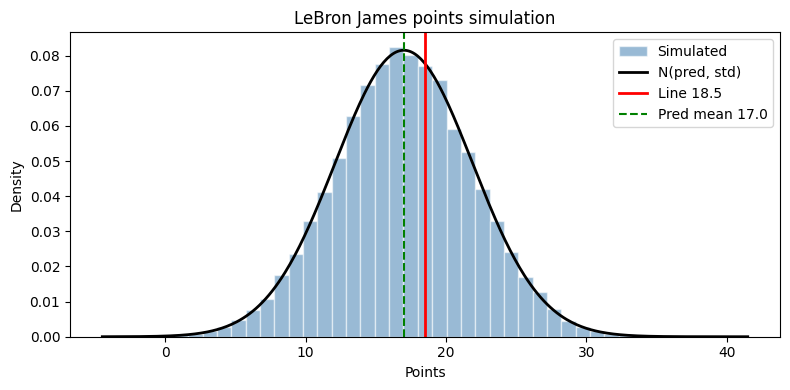

In [54]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

player = "LeBron James"
line = 18.5   # sportsbook line
predicted_points = 17                         # <- your model prediction

# Option A: historical game-to-game volatility
pdf = df[df["PLAYER_ID"] == 2544].sort_values("GAME_DATE")
std = float(pdf["PTS"].tail(20).std())

# Guardrail if std too small / NaN
if not np.isfinite(std) or std < 1.0:
    std = 4.5

rng = np.random.default_rng(42)
samples = rng.normal(loc=predicted_points, scale=std, size=50_000)

over_prob = (samples > line).mean()
under_prob = (samples < line).mean()

print(f"{player} | Pred={predicted_points:.2f} | Line={line:.2f} | Std={std:.2f}")
print(f"Over {over_prob:.2%} | Under {under_prob:.2%}")

# Optional: fair odds
p_over = np.clip(over_prob, 1e-6, 1 - 1e-6)
p_under = np.clip(under_prob, 1e-6, 1 - 1e-6)
fair_over_american = -100 * p_over/(1-p_over) if p_over >= 0.5 else 100 * (1-p_over)/p_over
fair_under_american = -100 * p_under/(1-p_under) if p_under >= 0.5 else 100 * (1-p_under)/p_under
print(f"Fair Over odds: {fair_over_american:.0f}, Fair Under odds: {fair_under_american:.0f}")

# Visual
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(samples, bins=45, density=True, alpha=0.55, color="steelblue", edgecolor="white", label="Simulated")
xs = np.linspace(samples.min(), samples.max(), 400)
ax.plot(xs, norm.pdf(xs, loc=predicted_points, scale=std), color="black", lw=2, label="N(pred, std)")
ax.axvline(line, color="red", lw=2, label=f"Line {line:g}")
ax.axvline(predicted_points, color="green", ls="--", lw=1.5, label=f"Pred mean {predicted_points:.1f}")
ax.set_xlabel("Points")
ax.set_ylabel("Density")
ax.set_title(f"{player} points simulation")
ax.legend()
plt.tight_layout()
plt.show()

Predicted: 16.99 | Hist mean: 18.70 | n_games: 10
Over 30.05% | under 69.95%
Sim mean: 16.71 | Sim median: 16.0 | Sim std: 5.12 | Line: 18.50


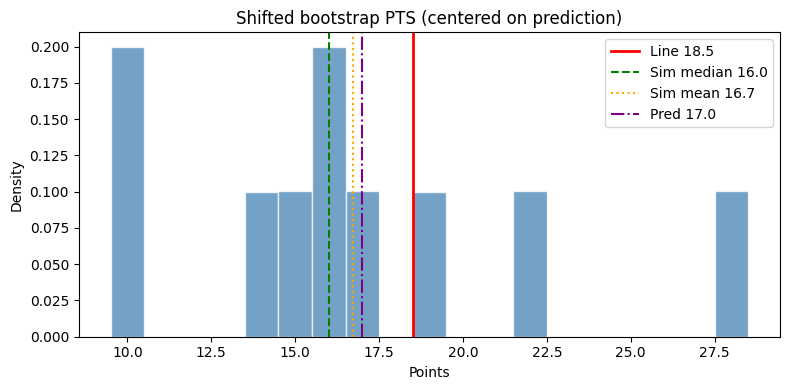

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# --- presets ---
predicted_points = 16.99  # from your model (proj_pts)
line = 18.5               # from sportsbook

player_id = 2544         # LeBron id
n_sims = 100_000
rng = np.random.default_rng()

# --- history for bootstrap (must come from game log data with PTS) ---
pdf = df[df["PLAYER_ID"] == player_id].sort_values("GAME_DATE")
pts_history = pd.to_numeric(pdf["PTS"].tail(10), errors="coerce").dropna().values
if len(pts_history) < 3:
    raise ValueError("Need a few games in pts_history for bootstrap.")

# Shift bootstrapped historical samples so mean == predicted_points
hist_mean = float(np.mean(pts_history))
samples = rng.choice(pts_history, size=n_sims, replace=True) + (predicted_points - hist_mean)

# Sportsbook PTS are integers
samples_int = np.clip(np.rint(samples), 0, None).astype(int)

# Over/under (works for .5 lines: e.g., over 18.5 => 19+)
over_prob = (samples_int > line).mean()
under_prob = (samples_int < line).mean()

print(f"Predicted: {predicted_points:.2f} | Hist mean: {hist_mean:.2f} | n_games: {len(pts_history)}")
print(f"Over {over_prob:.2%} | under {under_prob:.2%}")
print(
    f"Sim mean: {samples_int.mean():.2f} | Sim median: {np.median(samples_int):.1f} | "
    f"Sim std: {samples_int.std(ddof=1):.2f} | Line: {line:.2f}"
)

# Visual
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(samples_int.min() - 0.5, samples_int.max() + 1.5, 1)
ax.hist(samples_int, bins=bins, density=True, alpha=0.75, color="steelblue", edgecolor="white")

ax.axvline(line, color="red", lw=2, label=f"Line {line:g}")
ax.axvline(np.median(samples_int), color="green", ls="--", lw=1.5, label=f"Sim median {np.median(samples_int):.1f}")
ax.axvline(np.mean(samples_int), color="orange", ls=":", lw=1.5, label=f"Sim mean {np.mean(samples_int):.1f}")
ax.axvline(predicted_points, color="purple", ls="-.", lw=1.5, label=f"Pred {predicted_points:.1f}")

ax.set_xlabel("Points")
ax.set_ylabel("Density")
ax.set_title("Shifted bootstrap PTS (centered on prediction)")
ax.legend()
plt.tight_layout()
plt.show()

Negative binomial (mean from model, variance from L10 history)
  fitted n=23.7928, p=0.58340
  target mu=16.99, target var=29.12
  sim mean=16.98, sim var=28.91
Over 36.30% | under 63.70%


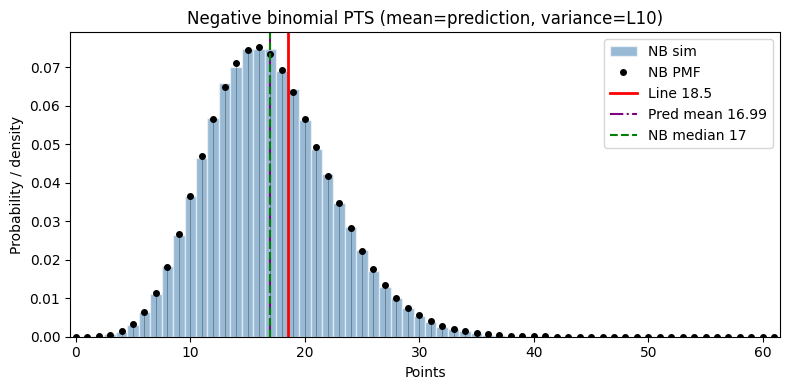

In [61]:
from scipy.stats import nbinom
import numpy as np
import matplotlib.pyplot as plt

# --- presets ---
player_id = 2544
predicted_points = 16.99   # model output
line = 18.5                # sportsbook line
n_sims = 100_000

# --- history (for variance / dispersion) ---
pdf = df[df["PLAYER_ID"] == player_id].sort_values("GAME_DATE")
pts_history = pd.to_numeric(pdf["PTS"].tail(10), errors="coerce").dropna().values
if len(pts_history) < 3:
    raise ValueError("Need a few games in pts_history for NB fit.")

# Use model prediction as mean, historical variance as uncertainty
mu = float(predicted_points)
hist_var = float(np.var(pts_history, ddof=1)) if len(pts_history) > 1 else mu

# Ensure NB is valid: variance must be > mean
var = max(hist_var, mu * 1.001)

# scipy NB parameterization:
# mean = n*(1-p)/p, var = n*(1-p)/p^2
# => p = mu/var, n = mu*p/(1-p)
p_nb = mu / var
n_nb = max(mu * p_nb / (1.0 - p_nb), 1e-6)

rng = np.random.default_rng(42)
samples_nb = nbinom.rvs(n_nb, p_nb, size=n_sims, random_state=rng)

over_prob = (samples_nb > line).mean()
under_prob = (samples_nb < line).mean()
push_prob = (samples_nb == line).mean() if float(line).is_integer() else 0.0

print("Negative binomial (mean from model, variance from L10 history)")
print(f"  fitted n={n_nb:.4f}, p={p_nb:.5f}")
print(f"  target mu={mu:.2f}, target var={var:.2f}")
print(f"  sim mean={samples_nb.mean():.2f}, sim var={samples_nb.var(ddof=1):.2f}")
print(f"Over {over_prob:.2%} | under {under_prob:.2%}" + (f" | push {push_prob:.2%}" if push_prob > 0 else ""))

# --- Visual ---
k_max = int(max(samples_nb.max(), line) + 8)
ks = np.arange(0, k_max + 1)
pmf = nbinom.pmf(ks, n_nb, p_nb)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(-0.5, k_max + 1.5, 1)
ax.hist(samples_nb, bins=bins, density=True, alpha=0.55, color="steelblue", edgecolor="white", label="NB sim")
ax.plot(ks, pmf, "ko", ms=4, label="NB PMF")
ax.vlines(ks, 0, pmf, colors="black", lw=0.6, alpha=0.35)
ax.axvline(line, color="red", lw=2, label=f"Line {line:g}")
ax.axvline(mu, color="purple", ls="-.", lw=1.5, label=f"Pred mean {mu:.2f}")
ax.axvline(nbinom.median(n_nb, p_nb), color="green", ls="--", lw=1.5, label=f"NB median {nbinom.median(n_nb, p_nb):.0f}")
ax.set_xlabel("Points")
ax.set_ylabel("Probability / density")
ax.set_title("Negative binomial PTS (mean=prediction, variance=L10)")
ax.set_xlim(-0.5, k_max + 0.5)
ax.legend()
plt.tight_layout()
plt.show()